In [1]:
import numpy as np
import scipy.constants as sc
import catppuccin
import adri
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)
from IPython.display import display, HTML
import inspect, re
def print_design_summary(*args):
    # Récupère les noms des variables depuis l'appel
    frame = inspect.currentframe().f_back
    call_source = inspect.getframeinfo(frame).code_context[0].strip()
    match = re.search(r'print_design_summary\((.*)\)', call_source)
    if match:
        arg_names = [a.strip() for a in match.group(1).split(',')]
    else:
        arg_names = [f"Block {i}" for i in range(len(args))]

    def make_table(title, blk):
        items = [(k, fmt(np.asarray(v).flat[0] if not np.isscalar(v) else v, k))
                 for k, v in blk.items()]
        header = (f"<tr><td colspan='2' style='padding:8px 0 3px; font-size:20px; "
                  f"letter-spacing:.1em; opacity:.5; text-transform:uppercase; "
                  f"border-top:1px solid currentColor;'>{title}</td></tr>")
        rows = "".join(
            f"<tr><td style='padding:1px 4px 1px 0; opacity:.6; white-space:nowrap'>{k}</td>"
            f"<td style='padding:1px 0; text-align:right; font-variant-numeric:tabular-nums; "
            f"font-weight:500; white-space:nowrap'>{v}</td></tr>"
            for k, v in items)
        footer = "<tr><td colspan='2' style='border-top:1px solid currentColor; padding-top:2px'></td></tr>"
        return (f"<table style='font-family:monospace; font-size:18px; border-collapse:collapse; "
                f"color:inherit; vertical-align:top'>{header}{rows}{footer}</table>")

    tables = ""
    for name, blk in zip(arg_names, args):
        tables += f"<td style='vertical-align:top; padding-right:0px'>{make_table(name, blk)}</td>"

    display(HTML(
        f"<table style='color:inherit; border-spacing:; border-collapse:collapse'>"
        f"<tr>{tables}</tr></table>"
    ))
def fmt(val, key=""):
    if not isinstance(val, (int, float, np.floating)):
        return str(val)
    a = abs(val)
    if   a >= 1e9:  return f"{val/1e9:.4g} G"
    elif a >= 1:    return f"{val:.4g}"
    elif a >= 1e-3: return f"{val/1e-3:.4g} m"
    elif a >= 1e-6: return f"{val/1e-6:.4g} u"
    elif a >= 1e-9: return f"{val/1e-9:.4g} n"
    elif a >= 1e-12:return f"{val/1e-12:.4g} p"
    else:           return f"{val:.4e}"



# 5T OTA Switched CAP  
 Size the OTA under given noise and settling speed constraints  

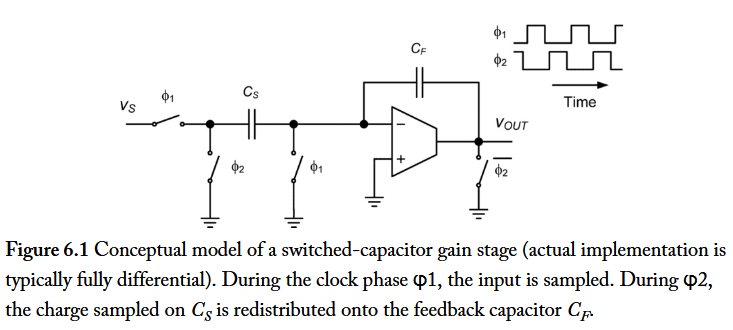 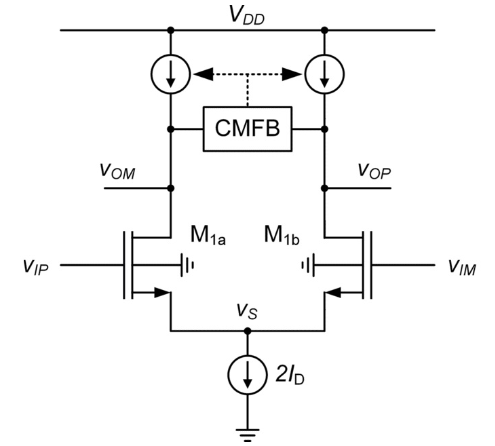 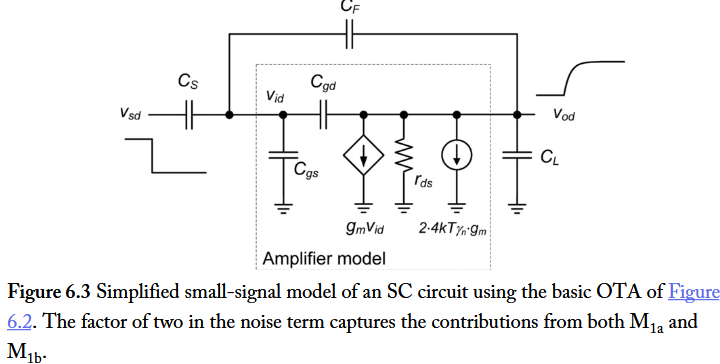

## Formulas  
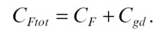 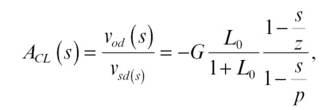 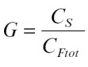 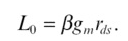 
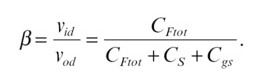 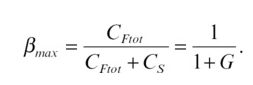  
 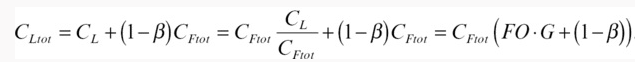  
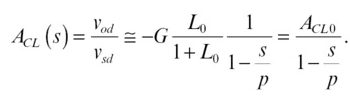 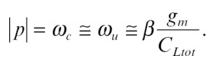 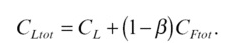 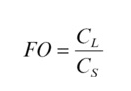  
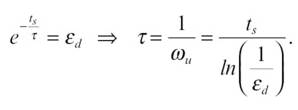 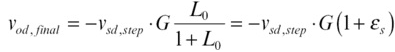 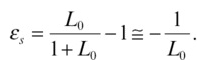 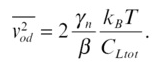  
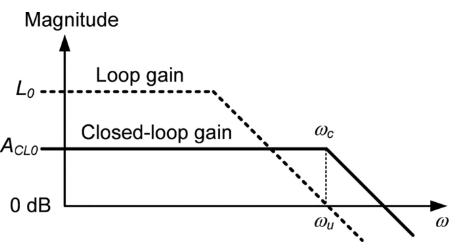

base : 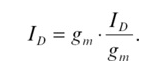 -> Solve this for gm  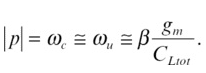  Replace Cltot with 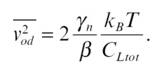  
 => 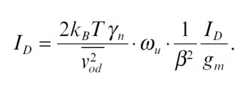 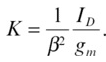  
 Id = F(Noise, bandwidth, beta, gm_id)  
 For set Noise & BW : Minimize K == Maximize Beta &  gm_id  
 **====> PB : More GM_ID == More C_GS == Less Beta**

 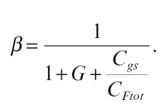 whith 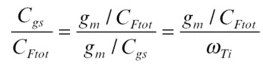 && 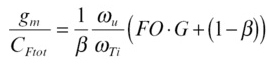 from 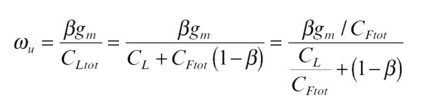 && 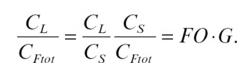  
 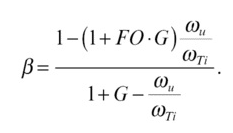
 => 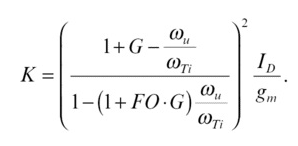  

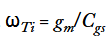 

 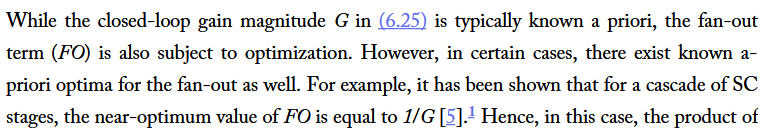  
 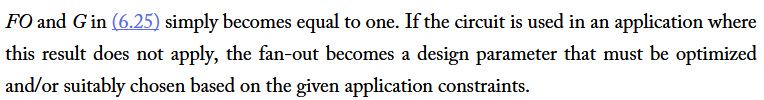  
 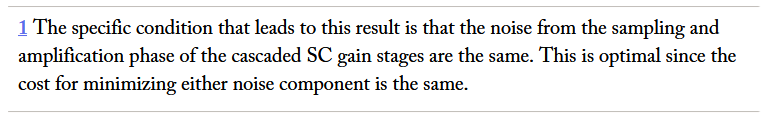

What to do ??  Id = F(Noise, bandwidth, beta, gm_id), if noise & bendwidth are spec,, then Optimize K 

# Folded cascode for switched cap  

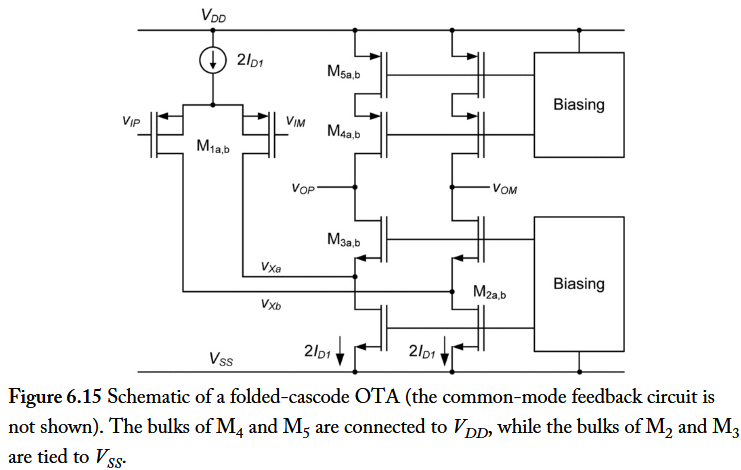  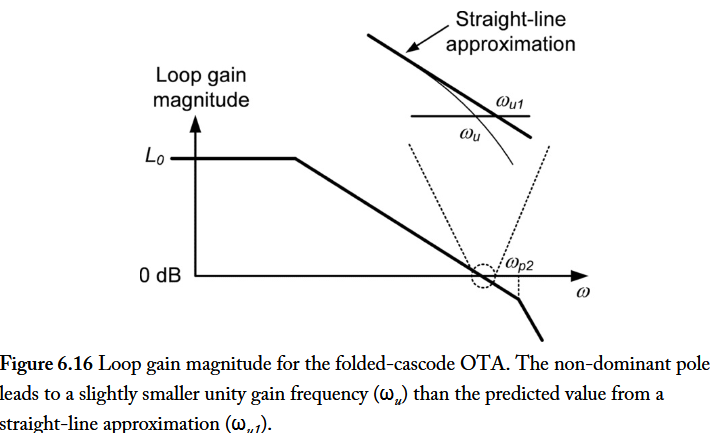  
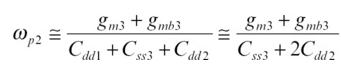 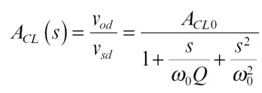 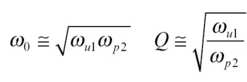  
__Source : Considerations for fast settling operational amplifiers => Wp2 / Wu1 = 4 = 75° marge phase -> Fastest settling without overshoot__  
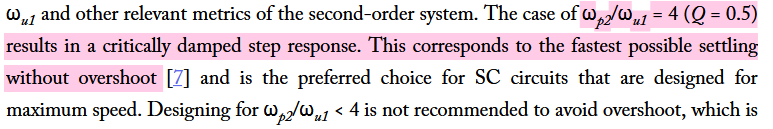 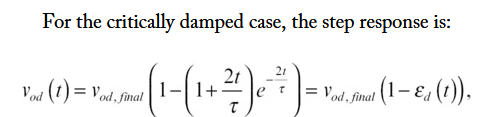 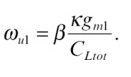   
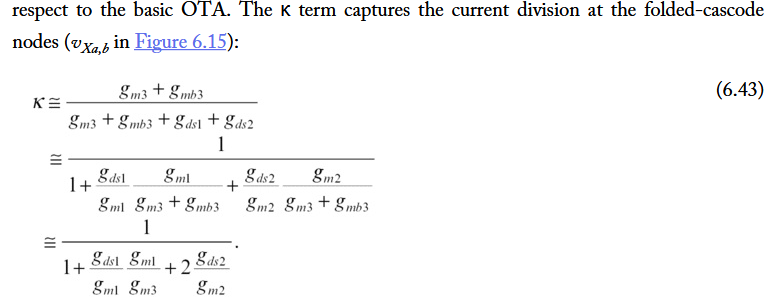 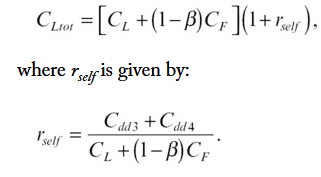 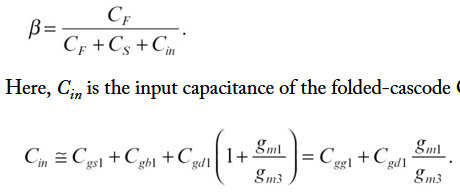  
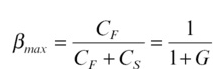 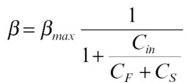 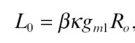 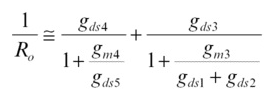  
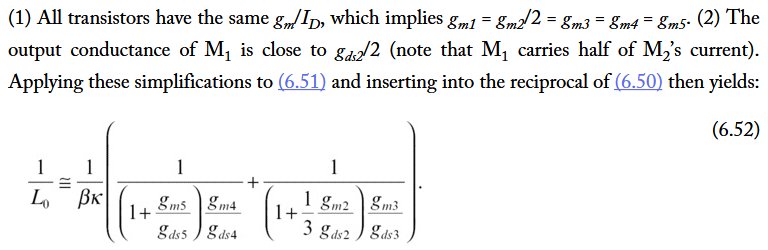 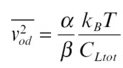 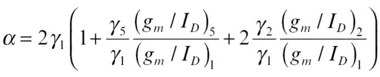  
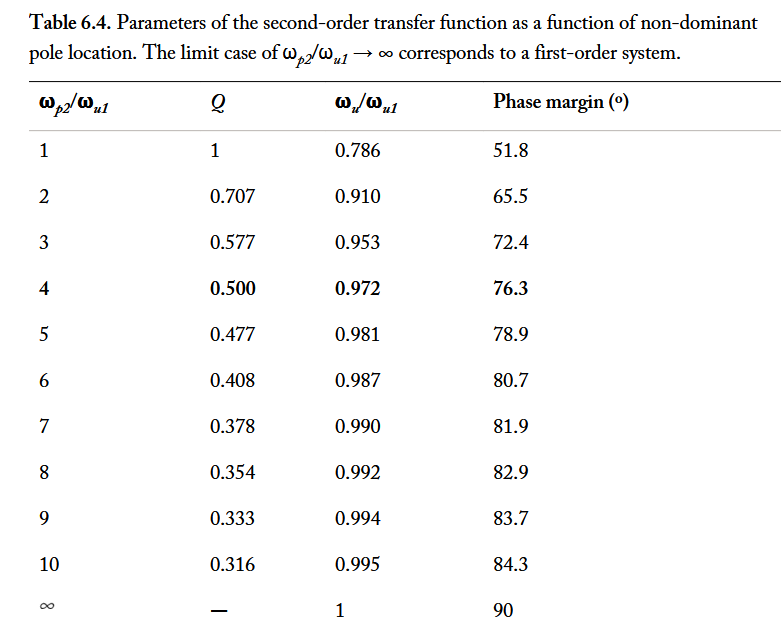

## STEP 1 : Sizing the output branch

2 MOS pour 0.45000000000000007
gm_id >  8.888888888888888
On prend gm_id = 15


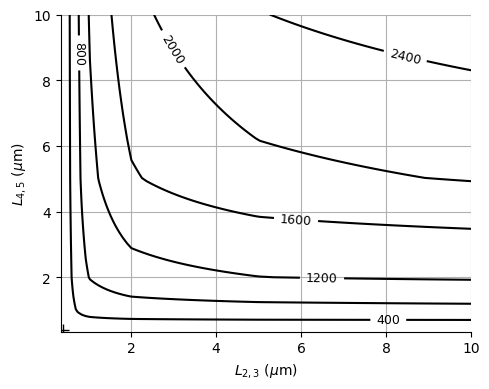

On prend L23 = 0.5
Nondominant pole frequency: 0.314 GHz


In [2]:
#Spec
#L0 > 50 & V_SWING_P2P_DIFF = 1.8

G = 2
beta_max = 1 / (1 + G)
beta = 3/4 * beta_max
kappa = 0.7

#Sizing the output branch

#Vout_cm = 1.35
###Choose gm_id with output common mode
#Vout_swing = 1.8 p2p_diff -> each output 0.9 p2p -> 1.35 +- 0.45
VDD = 2.7
VCM = 1.35
V_SWING_P2P_DIFF = 1.8
VOUT_CM_HIGH = VCM+V_SWING_P2P_DIFF/2
VOUT_CM_LOW = VCM-V_SWING_P2P_DIFF/2
print('2 MOS pour', VOUT_CM_LOW)
gm_id = 2/(VOUT_CM_LOW/2)
print('gm_id > ', gm_id)
print('On prend gm_id = 15')
##On prend gm_id = 15
gm_ID = 15

###Choose L with gain target, calc gain pour plot

L = np.linspace(0.35, 10, 100)

gm_gds2 = nmos4.lookup('GM_GDS', GM_ID = gm_ID, L = L, VDS = 0.2, VSB = 0)
gm_gds3 = nmos4.lookup('GM_GDS', GM_ID = gm_ID, L = L, VDS = 0.4, VSB = -0.2)
gm_gds4 = pmos4.lookup('GM_GDS', GM_ID = gm_ID, L = L, VDS = 0.4, VSB = -0.2)
gm_gds5 = pmos4.lookup('GM_GDS', GM_ID = gm_ID, L = L, VDS = 0.2, VSB = 0)

L0 = np.zeros((len(L), len(L)))
#Copute L0 for range of Lcascode
for i in range(len(L)):
    L0[i, :] = beta * kappa / (1/((1+gm_gds5)*gm_gds4) + 1/((1+1/3*gm_gds2[i])*gm_gds3[i]))

# Plotting
fig, ax = plt.subplots(figsize=(5, 4))

C = ax.contour(L, L, L0, colors='k')
ax.clabel(C, fmt='%d', fontsize=9)
ax.set_xlabel(r'$L_{2,3}$ ($\mu$m)')
ax.set_ylabel(r'$L_{4,5}$ ($\mu$m)')
ax.plot(0.4, 0.4, 'k+', markersize=9, linewidth=20)

plt.tight_layout()
plt.show()

#Choose length
L23 = 0.5
print('On prend L23 =', L23)
gmb_gm3 =   nmos4.lookup('GMB_GM', GM_ID = gm_ID, L = L23, VDS = 0.4, VSB = -0.2)
gm_css3 =   nmos4.lookup('GM_CSS', GM_ID = gm_ID, L = L23, VDS = 0.4, VSB = -0.2)
cdd_css3 =  nmos4.lookup('CDD_CSS', GM_ID = gm_ID, L = L23, VDS = 0.4, VSB = -0.2)
cdd_w3  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID, L = L23, VDS = 0.4, VSB = -0.2)
cdd_w2  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID, L = L23, VDS = 0.2, VSB = 0)

# Nondominant pole frequency
fp2 = 1 / (2 * np.pi) * gm_css3 * (1 + gmb_gm3) / (1 + 2 * cdd_css3 * 2 * (cdd_w2 / cdd_w3))
print(f'Nondominant pole frequency: {fp2 * 1e-9:.3f} GHz')

## STEP 2 :  Input stage 
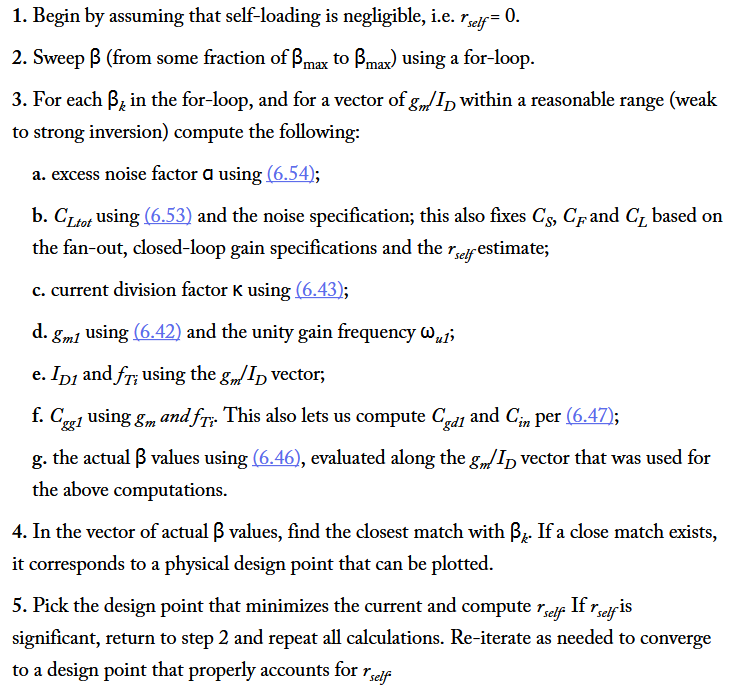

### Folded cascode function loop  

In [3]:
def old_folded_cascode(nmoslk, pmoslk,  s, d): ##Version LOOP FOR
    # ─── Algorithm ────────────────────────────────────────────────────────────────
    #
    # 1. Begin by assuming that self-loading is negligible, i.e. r_self = 0.
    # 2. Sweep β (from some fraction of β_max to β_max) using a for-loop.
    # 3. For each β_k in the for-loop, and for a vector of gm/ID within a reasonable
    #    range (weak to strong inversion) compute the following:
    #    a. excess noise factor α using (6.54)
    #    b. C_Ltot using (6.53) and the noise specification; this also fixes C_S, C_F
    #       and C_L based on the fan-out, closed-loop gain specifications and the r_self estimate.
    #    c. current division factor κ using (6.43)
    #    d. g_m1 using (6.42) and the unity gain frequency ω_u1
    #    e. I_D1 and f_Ti using the gm/ID vector
    #    f. C_gg1 using g_m and f_Ti. This also lets us compute C_gd1 and C_in
    #       per (6.47)
    #    g. the actual β values using (6.46), evaluated along the gm/ID vector
    #       that was used for the above computations.
    # 4. In the vector of actual β values, find the closest match with β_k. If a
    #    close match exists, it corresponds to a physical design point that can
    #    be plotted.
    # 5. Pick the design point that minimizes the current and compute r_self.
    #    If r_self is significant, return to step 2 and repeat all calculations.
    #    Re-iterate as needed to converge to a design point that properly
    #    accounts for r_self.

    #     s = {
    #     'ts'        : 50e-9,
    #     'ed'        : 0.1/100,
    #     'fu1'       : 1/(2*np.pi) * np.log(1/ 0.1/100) / 50e-9,
    #     'vod_noise' : 400e-6,
    #     'FO'        : 0.5,
    #     'G'         : 2
    # }
    # beta_max = 1 / (1 + s['G'])
    # s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']

    # # Constants for another design
    # d = {
    #     'gamma': 0.7,
    #     'Lcas': 0.5,
    #     'gm_IDcas': 15,
    #     'cself': 0,
    #     'gm_ID1': np.linspace(3, 27, 100),
    #     'beta': beta_max * np.linspace(0.2, 1, 100)
    # }

    kB = 1.3806488e-23

    # Fetch device parameters
    gm_gds1 = pmoslk.look_up( 'GM_GDS', GM_ID=d['gm_ID1'], L=d['L1'])
    wt1 = pmoslk.look_up( 'GM_CGG', GM_ID=d['gm_ID1'], L=d['L1'])
    cgd_cgg1 = pmoslk.look_up( 'CGD_CGG', GM_ID=d['gm_ID1'], L=d['L1'])
    gm_gds2 = nmoslk.look_up( 'GM_GDS', GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm3 = nmoslk.look_up( 'CDD_GM', GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm4 = pmoslk.look_up( 'CDD_GM', GM_ID=d['gm_IDcas'], L=d['Lcas'])

    # Initialize output structures
    m1 = {'ID': np.full(len(d['beta']), np.nan), 'gm_ID': np.full(len(d['beta']), np.nan)}
    p = {'cltot': np.full(len(d['beta']), np.nan), 'cself': np.full(len(d['beta']), np.nan)}

    for j in range(len(d['beta'])):
        ##Pour un beta, on va faire des calculs avec une range de gm_id
        ##Indice j == pour ce beta
        ##Calc Cltot avec noise, puis les autre CAP
        beta = d['beta'][j]
        alpha = 2 * d['gamma'] * (1 + d['gm_IDcas'] / d['gm_ID1'] + 2 * d['gm_IDcas'] / d['gm_ID1'])
        cltot = alpha / beta * kB * 300 / s['vod_noise'] ** 2
        CF = (cltot - d['cself']) / (s['FO'] * s['G'] + 1 - beta)
        CS = s['G'] * CF
        ##Calc gm from unity gain bandwidth puis ID
        kappa = 1 / (1 + 1 / gm_gds1 * d['gm_ID1'] / d['gm_IDcas'] + 2 / gm_gds2)
        gm1 = 2 * np.pi * s['fu1'] * cltot / beta / kappa
        ID1 = gm1 / d['gm_ID1']
        ##Compute input cap for real beta
        cgs1 = gm1 / wt1
        cin = cgs1 * (1 + cgd_cgg1 * d['gm_ID1'] / d['gm_IDcas'])
        beta_actual = CF / (CF + CS + cin)
        ##Trouve l'indice ou beta_actual est le plus proche de beta
        m = np.argmin(np.abs(beta_actual - beta))

        m1['ID'][j] = ID1[m]
        m1['gm_ID'][j] = d['gm_ID1'][m]
        p['cltot'][j] = cltot[m]

    # Compute self-loading
    gm34 = m1['ID'] * d['gm_IDcas']
    p['cself'] = gm34 * cdd_gm3 + gm34 * cdd_gm4

    return m1, p


### Folded cascode function vectorized

In [4]:
def folded_cascode(nmoslk, pmoslk, s, d): ##Version Matriced
    """
    Size a folded-cascode amplifier using the gm/ID methodology.

    Sweeps β and gm/ID simultaneously to find the design points that meet
    the noise and speed specifications, then computes the self-loading
    capacitance at each point.

    nmoslk / pmoslk are gm/ID lookup tables for the NMOS and PMOS devices.

    s must contain:
        fu1       — unity-gain frequency (Hz)
        vod_noise — output-referred noise voltage (V)
        FO        — fan-out
        G         — closed-loop gain
        vod_final — voltage ouput step max
        ed — erreur settling %

    d must contain:
        gm_ID1   — gm/ID sweep vector for the input transistor (S/A)
        beta     — feedback factor sweep vector
        L1       — input transistor length (µm)
        Lcas     — cascode length (µm)
        gm_IDcas — cascode gm/ID operating point (S/A)
        gamma    — excess noise coefficient
        cself    — self-loading estimate, set to 0 on first pass (F)

    Returns m1 (ID, gm_ID) and p (cltot, cself) at each matched design point.
    """
    kB = 1.3806488e-23
    temp = 300
    # ── Device lookups over the gm/ID sweep vector ────────────────────────────
    gm_gds1  = pmoslk.look_up('GM_GDS',  GM_ID=d['gm_ID1'],   L=d['L1'])
    wt1      = pmoslk.look_up('GM_CGG',  GM_ID=d['gm_ID1'],   L=d['L1'])
    cgd_cgg1 = pmoslk.look_up('CGD_CGG', GM_ID=d['gm_ID1'],   L=d['L1'])
    gm_gds2  = nmoslk.look_up('GM_GDS',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm3  = nmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm4  = pmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])

    # ── Step 2 : sweep β — broadcast to 2D (N_beta, N_gm_ID1) ────────────────
    beta   = d['beta'][:, None]    # (N, 1)
    gm_ID1 = d['gm_ID1'][None, :] # (1, M)

    # Step 3a. Excess noise factor α (eq. 6.54)
    alpha = 2 * d['gamma'] * (1 + 3 * d['gm_IDcas'] / gm_ID1)

    # Step 3b. C_Ltot from noise spec (eq. 6.53) — also fixes C_S, C_F, C_L
    cltot = alpha / beta * kB * temp / s['vod_noise']**2
    CF    = (cltot - d['cself']) / (s['FO'] * s['G'] + 1 - beta)
    CS    = s['G'] * CF
    CL   = s['FO'] * CS

    # Step 3c. Current division factor κ (eq. 6.43)
    kappa = 1 / (1 + gm_ID1 / (gm_gds1 * d['gm_IDcas']) + 2 / gm_gds2)

    #Slewing compute X, then more accurate wu1 
    X = s['vod_final'] * beta / 2 * gm_ID1
    wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))

    # Step 3d. g_m1 from settling formula above 
    #gm1 = 2 * np.pi * s['fu1'] * cltot / beta / kappa
    gm1 = wu1 * cltot / beta / kappa

    # Step 3e. I_D1 and f_Ti from the gm/ID vector
    ID1 = gm1 / gm_ID1

    # Step 3f. C_gg1 from g_m and f_Ti → compute C_gd1 and C_in (eq. 6.47)
    cgs1 = gm1 / wt1
    cin  = cgs1 * (1 + cgd_cgg1 * gm_ID1 / d['gm_IDcas'])

    # Step 3g. Actual β values along the gm/ID vector (eq. 6.46)
    beta_actual = CF / (CF + CS + cin)

    # ── Step 4 : find closest match between β_actual and β_k ─────────────────
    idx = np.argmin(np.abs(beta_actual - beta), axis=1)  # (N,)
    j   = np.arange(len(d['beta']))




    m1_gm1 = gm1[j, idx]
    m1_gm_id1 = d['gm_ID1'][idx]
    ID1 = gm1[j, idx] / d['gm_ID1'][idx]
    
    #Fill output with MOS charac
    m1 = adri.get_all_mos(pmos4, GM_ID=m1_gm_id1,L=d['L1'], GM=m1_gm1, ID=ID1)
    m2 = adri.get_all_mos(nmos4, GM_ID=d['gm_IDcas'], L=d['Lcas'], ID=2*ID1, VDS=0.2)
    m3 = adri.get_all_mos(nmos4, GM_ID=d['gm_IDcas'], L=d['Lcas'], ID=ID1, VDS=0.2)
    m4 = adri.get_all_mos(pmos4, GM_ID=d['gm_IDcas'], L=d['Lcas'], ID=ID1, VDS=0.2)
    m5 = adri.get_all_mos(pmos4, GM_ID=d['gm_IDcas'], L=d['Lcas'], ID=ID1, VDS=0.2)

    p = {
        'cltot': cltot[j, idx],
        'cself': m1['ID'] * d['gm_IDcas'] * (cdd_gm3 + cdd_gm4),  # → r_self = cself/cltot
        #'beta' : beta,
        'L0' : L0,
        'CF' : CF,
        'CS' : CS,
        'CL' : CL,
        #'beta_betamax' : beta_betamax,
    }



    # m1 = {
    #     'ID':    gm1[j, idx] / d['gm_ID1'][idx],
    #     'GM_ID': d['gm_ID1'][idx],
    # }
    # p = {
    #     'cltot': cltot[j, idx],
    #     'cself': m1['ID'] * d['gm_IDcas'] * (cdd_gm3 + cdd_gm4),  # → r_self = cself/cltot
    # }
    return m1,m2,m3,m4,m5,p

### Find Lowest current & Rself versus length & gm_id1

FP2 / FU1 == 4 for 75° phase margin and fatest settling
fp2 / s['fu1'] = np.float64(14.298976633190415)


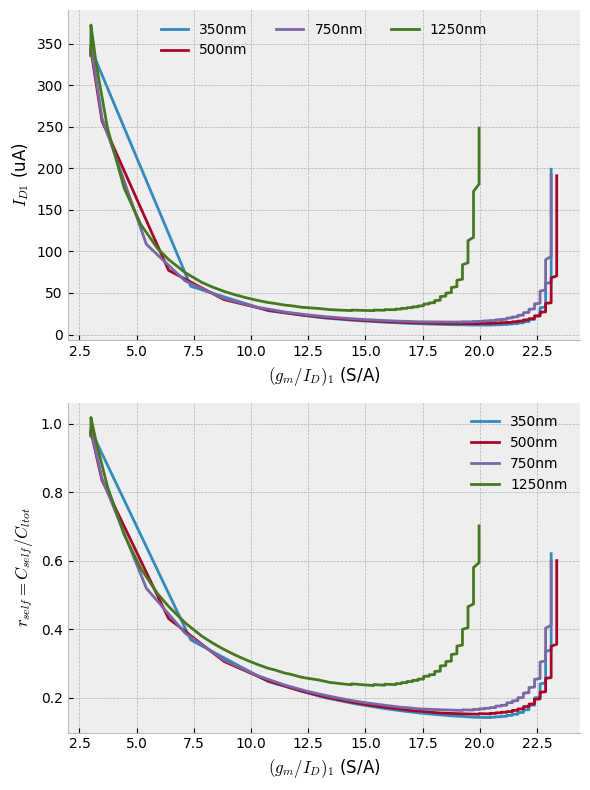

In [5]:
#Design Spec 
s = {
    'ts'        : 50e-9,
    'ed'        : 0.1/100,
    'fu1'       : 1/(2*np.pi) * np.log(1/ (0.1/100)) / 50e-9,
    'vod_noise' : 400e-6,
    'FO'        : 0.5,
    'G'         : 2,
    'vod_final' : 0.2
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']

# Constants for another design
d = {
    'gamma': 0.8,
    'Lcas': 0.5,
    'gm_IDcas': 15,
    'cself': 0,
    'gm_ID1': np.linspace(3, 27, 100),
    'beta': beta_max * np.linspace(0.2, 1, 100)
}

# Channel length sweep
L1 = [0.35, 0.5, 0.75, 1.25]
m1 = []
p = []

for Li in L1:
    d['L1'] = Li
    mi,m2,m3,m4,m5,pi = folded_cascode(nmos4, pmos4, s, d)
    m1.append(mi)
    p.append(pi)

# Plotting setup
plt.style.use("bmh")
fig, axs = plt.subplots(2, 1, figsize=(6, 8))

# Plot ID versus gm/ID for different L values
for i, length in enumerate(L1):
    label = f'{length * 1e3:.0f}nm'  # Convert L from meters to nm for label
    axs[0].plot(m1[i]['GM_ID'], m1[i]['ID'] * 1e6, label=label)  # ID in mA
axs[0].set_xlabel(r'$(g_m/I_D)_1$ (S/A)')
axs[0].set_ylabel(r'$I_{D1}$ (uA)')
axs[0].legend(loc='upper center', ncol=3, frameon=False)
axs[0].grid(True)

# Plot cself/cltot versus gm/ID for different L values
for i, length in enumerate(L1):
    label = f'{length * 1e3:.0f}nm'
    axs[1].plot(m1[i]['GM_ID'], p[i]['cself'] / p[i]['cltot'], label=label)
axs[1].set_xlabel(r'$(g_m/I_D)_1$ (S/A)')
axs[1].set_ylabel(r'$r_{self} = C_{self}/C_{ltot}$')
axs[1].legend(loc='best', frameon=False)
axs[1].grid(True)

print("FP2 / FU1 == 4 for 75° phase margin and fatest settling")
adri.cool_print(fp2 / s['fu1'])

plt.tight_layout()
plt.show()

In [6]:
#Design Spec 
s = {
    'ts'        : 50e-9,
    'ed'        : 0.1/100,
    'fu1'       : 1/(2*np.pi) * np.log(1/ (0.1/100)) / 50e-9,
    'vod_noise' : 400e-6,
    'FO'        : 0.5,
    'G'         : 2,
    'vod_final' : 0.2
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']

# Constants for another design
d = {
    'gamma': 0.8,
    'Lcas': 0.5,
    'gm_IDcas': 15,
    'cself': 0,
    'L1': 0.5,
    'gm_ID1': np.array([15]),
    'beta': np.array([beta_max * 3/4])
}
m1,m2,m3,m4,m5,p = folded_cascode(nmos4, pmos4, s, d)

print_design_summary(d,s,m1,m2,m3,m4,m5,p)


### Self loading loop+Sizing W,L 

LO : 63.549 dB
gmid diff pair :  = 20.697
gmid casc :  = 8.000
Width W1:  = 354.782 um
Width W2:  = 13.847 um
Width W3:  = 6.924 um
Width W4:  = 22.307 um
Width W5:  = 22.307 um
CF:  = 9.2183 pF
CS:  = 2.3046 pF
CL:  = 0.2881 pF
L1:  = 0.5000 um
Lcasc:  = 0.5000 um
Ibias:  = 37.9518 uA
VGS_M2  = 0.77 V
VGS_M3  = 0.81 V
VGS_M4  = 0.96 V
VGS_M5  = 0.92 V
beta_opt / beta_max  = 0.935
fu1  = 27.485 MHz


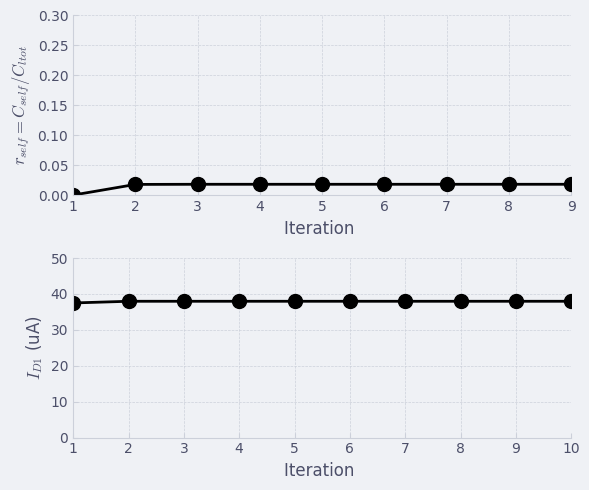

In [7]:
#With self loading now
#Design Spec 
s = {
    'ts'        : 40e-9,
    'ed'        : 0.1/100,
    'fu1'       : 1/(2*np.pi) * np.log(1/ 0.1/100) / 40e-9,
    'vod_noise' : 90e-6,
    'FO'        : 1/8,
    'G'         : 1/4,
    'vod_final' : 0.5
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']

# Constants for another design
d = {
    'gamma': 0.9,
    #To be adjust if noise not accurate or compute gamme
    'Lcas': 0.5,
    'gm_IDcas': 8,
    'L1' : 0.5,
    'cself': 0,
    'gm_ID1': np.linspace(3, 27, 100),
    'beta': beta_max * np.linspace(0.2, 1, 100)
}

# Self loading sweep
cself = np.zeros(10)
ID1 = np.zeros_like(cself)
gm_ID1 = np.zeros_like(cself)
cltot = np.zeros_like(cself)
beta = np.zeros_like(cself)

for i in range(len(cself)):
    d['cself'] = cself[i]
    #rint(d['cself'])
    m1,m2,m3,m4,m5,p = folded_cascode(nmos4, pmos4, s, d)
    ID1[i] = np.min(m1['ID'])
    m = np.argmin(m1['ID'])
    gm_ID1[i] = m1['GM_ID'][m]
    cltot[i] = p['cltot'][m]
    beta[i] = d['beta'][m]

    if i + 1 < len(cself):
        cself[i + 1] = p['cself'][m]

plt.style.use(catppuccin.PALETTE.latte.identifier)
# Plotting results
fig, axs = plt.subplots(2, 1, figsize=(6, 5))

# r_self vs iteration
axs[0].plot(range(1, len(cself)), cself[:-1] / cltot[:-1], 'k-o', linewidth=2, markersize=10)
axs[0].set_xlabel('Iteration ')
axs[0].set_ylabel(r'$r_{self} = C_{self}/C_{ltot}$')
axs[0].set_xlim([1, len(cself) - 1])
axs[0].set_ylim([0, 0.3])
axs[0].grid(True)

# ID1 vs iteration
axs[1].plot(range(1, len(ID1) + 1), ID1 * 1e6, 'k-o', linewidth=2, markersize=10)
axs[1].set_xlabel('Iteration ')
axs[1].set_ylabel(r'$I_{D1}$ (uA)')
axs[1].set_xlim([1, len(ID1)])
axs[1].set_ylim([0, 50])
axs[1].grid(True)

# Final sizing point
ID1_opt = ID1[-1]
gm_ID1_opt = gm_ID1[-1]
beta_opt = beta[-1]
CLtot = cltot[-1]
Cself = cself[-1]

# Computing capacitances
CF = (CLtot - Cself) / (s['FO'] * s['G'] + 1 - beta_opt)
CS = s['G'] * CF
CL = s['FO'] * CS

# Using lookup to get current densities
ID_W1 = pmos4.look_up( 'ID_W', GM_ID=gm_ID1_opt, L=d['L1'])
ID_W2 = nmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)
ID_W5 = pmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)

#######Calc GAIN
gds5    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * ID1_opt
gds4    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1_opt
gm4     = pmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1_opt
gds3    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1_opt
gm3     = nmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2) * ID1_opt
gds2    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * 2 * ID1_opt
gds1    = pmos4.look_up( 'GDS_ID', GM_ID=gm_ID1_opt, L=d['L1']) * 2 * ID1_opt
gds_gm1    = pmos4.look_up( 'GDS_GM', GM_ID=gm_ID1_opt, L=d['L1'])
gm_gds2    = nmos4.look_up( 'GM_GDS', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6)
gm1 = gm_ID1_opt * ID1_opt

rout = 1 / ( gds4 / (1+gm4/gds5) + gds3 / (1 + gm3 / (gds1+gds2) ))
kappa = 1 / ( 1 + gds1 / gm3 + 2 / gm_gds2)
L0 = 20*np.log10(beta_opt * kappa * gm1 * rout)

# Calculating widths
W1 = ID1_opt / ID_W1
W2 = 2 * ID1_opt / ID_W2
W3 = W2 / 2
W5 = ID1_opt / ID_W5
W4 = W5

#VGSs
VGS_M2 = nmos4.look_upVGS(GM_ID = d['gm_IDcas'], VDS = 0.2)
VGS_M3 = nmos4.look_upVGS(GM_ID = d['gm_IDcas'], VDS = 1.15, VSB = -0.2)
VGS_M4 = pmos4.look_upVGS(GM_ID = d['gm_IDcas'], VDS = 1.15, VSB = -0.2)
VGS_M5 = pmos4.look_upVGS(GM_ID = d['gm_IDcas'], VDS = 0.2)


# Printing the results


print('LO : %.3f dB' % L0)
print('gmid diff pair :  = %.3f' % gm_ID1_opt)
print('gmid casc :  = %.3f' % d['gm_IDcas'])
print('Width W1:  = %.3f um' % W1)
print('Width W2:  = %.3f um' % W2)
print('Width W3:  = %.3f um' % W3)
print('Width W4:  = %.3f um' % W4)
print('Width W5:  = %.3f um' % W5)
print('CF:  = %.4f pF' % (CF*1e12))
print('CS:  = %.4f pF' % (CS*1e12))
print('CL:  = %.4f pF' % (CL*1e12))
print('L1:  = %.4f um' % (d['L1']))
print('Lcasc:  = %.4f um' % (d['Lcas']))
print('Ibias:  = %.4f uA' % (ID1_opt*1e6))
print('VGS_M2  = %.2f V' % (VGS_M2))
print('VGS_M3  = %.2f V' % (VGS_M3))
print('VGS_M4  = %.2f V' % (VGS_M4))
print('VGS_M5  = %.2f V' % (VGS_M5))
print('beta_opt / beta_max  = %.3f' % (beta_opt / beta_max))
print('fu1  = %.3f MHz' % (s['fu1']*1e-6))

d['gm_ID1'] =  np.array([gm_ID1_opt])
d['beta'] =  np.array([beta_opt])
m1,m2,m3,m4,m5,p = folded_cascode(nmos4, pmos4, s, d)
print_design_summary(s,d,m1,m2,m3,m4,m5,p)

plt.tight_layout()
plt.show()


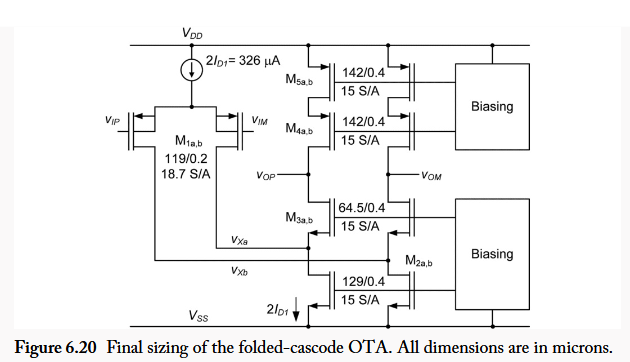  
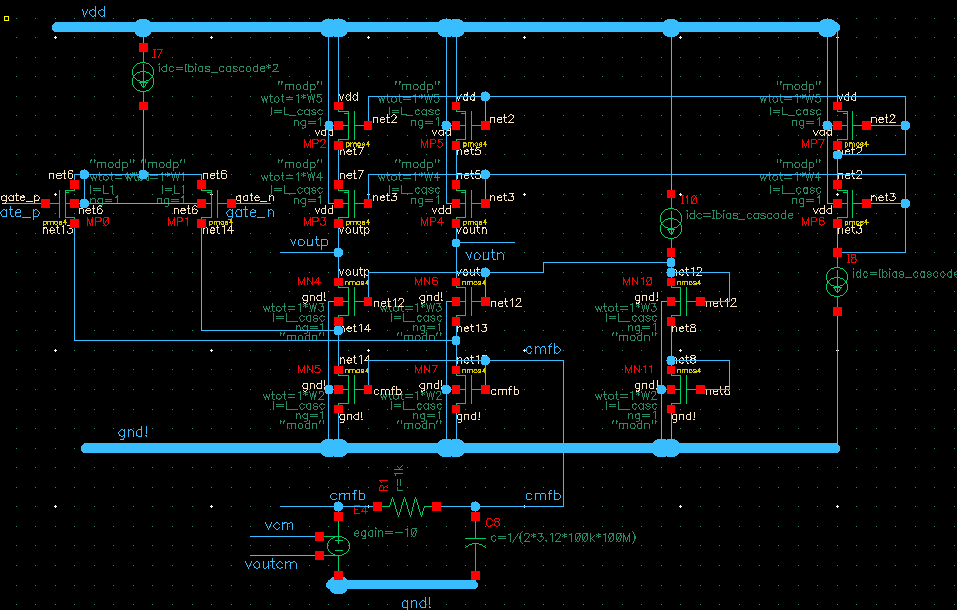  
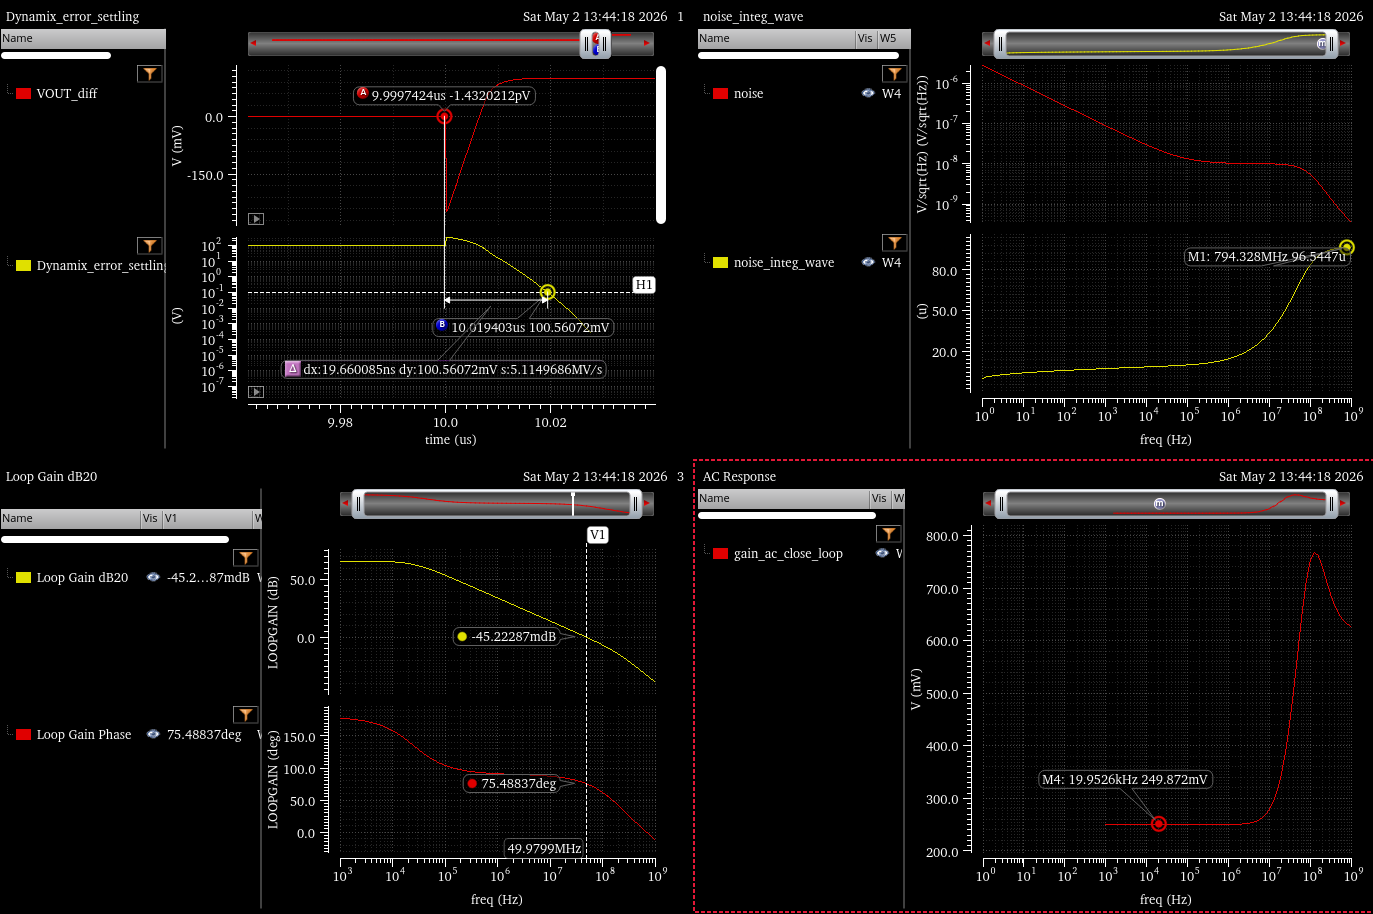  
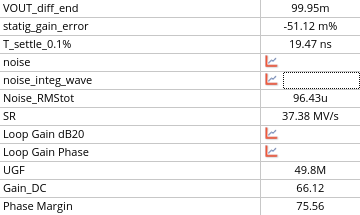

### Sampled plot

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.9s finished
C:\Users\Surfe\AppData\Local\Temp\ipykernel_51936\2202817209.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


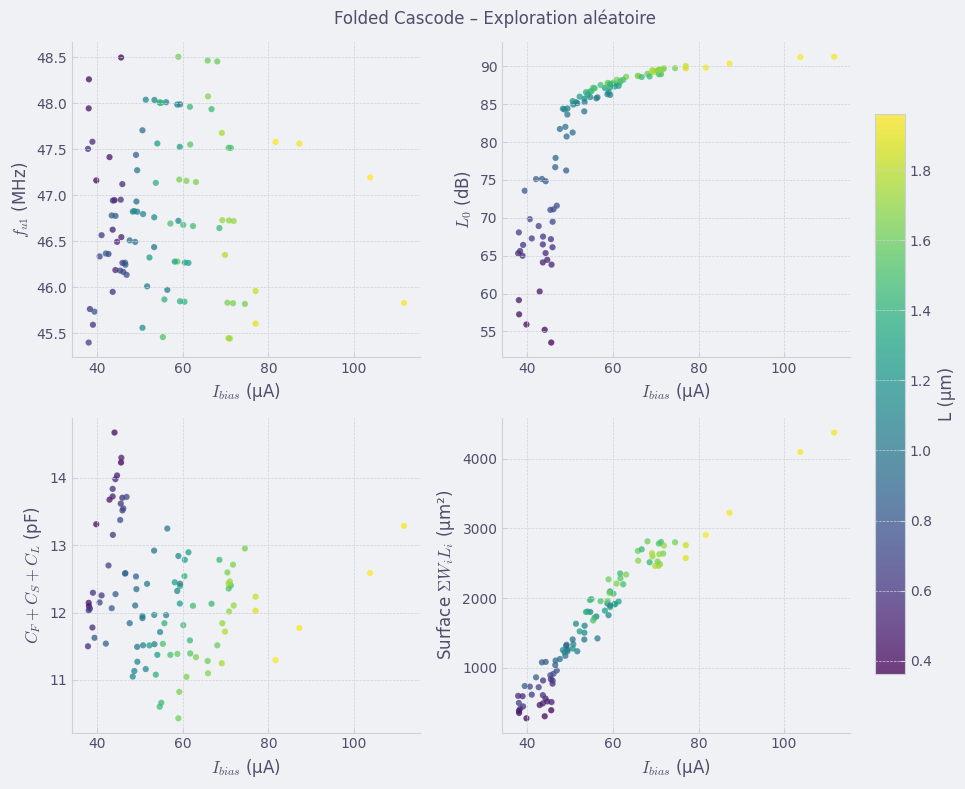

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import catppuccin
from joblib import Parallel, delayed

# ── Design spec ───────────────────────────────────────────────────────────────
s = {
    'ts'        : 40e-9,
    'ed'        : 0.1 / 100,
    'vod_noise' : 90e-6,
    'FO'        : 1 / 8,
    'G'         : 1 / 4,
    'vod_final' : 0.5,
}
s['fu1']  = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']
beta_max  = 1 / (1 + s['G'])

_gm_ID1 = np.linspace(3, 27, 40)   # réduit à 40 pts
_beta   = beta_max * np.linspace(0.2, 1, 40)


# ── Fonction principale ────────────────────────────────────────────────────────
def design_folded_cascode(L, gm_IDcas):
    d = {
        'gamma'    : 0.9,
        'Lcas'     : L,
        'gm_IDcas' : gm_IDcas,
        'L1'       : L,
        'cself'    : 0.0,
        'gm_ID1'   : _gm_ID1,
        'beta'     : _beta,
    }

    cself = 0.0
    ID1_opt = gm_ID1_opt = beta_opt = CLtot = Cself = 0.0

    for _ in range(4):
        d['cself'] = cself
        m1,m2,m3,m4,m5,p     = folded_cascode(nmos4, pmos4, s, d)
        idx       = np.argmin(m1['ID'])
        cself_new = p['cself'][idx]

        ID1_opt    = m1['ID'][idx]
        gm_ID1_opt = m1['GM_ID'][idx]
        beta_opt   = d['beta'][idx]
        CLtot      = p['cltot'][idx]
        Cself      = cself

        if cself > 0 and abs(cself_new - cself) / cself < 1e-3:
            break
        cself = cself_new

    CF   = (CLtot - Cself) / (s['FO'] * s['G'] + 1 - beta_opt)
    CS   = s['G']  * CF
    CL   = s['FO'] * CS
    Ctot = CF + CS + CL

    ID_W1   = pmos4.look_up('ID_W',   GM_ID=gm_ID1_opt, L=L)
    ID_W2   = nmos4.look_up('ID_W',   GM_ID=gm_IDcas,   L=L, VDS=0.2)
    ID_W5   = pmos4.look_up('ID_W',   GM_ID=gm_IDcas,   L=L, VDS=0.2)

    gds5    = pmos4.look_up('GDS_ID', GM_ID=gm_IDcas,   L=L, VDS=0.6)            * ID1_opt
    gds4    = pmos4.look_up('GDS_ID', GM_ID=gm_IDcas,   L=L, VDS=1.2, VSB=-0.6) * ID1_opt
    gm4     = pmos4.look_up('GM_ID',  GM_ID=gm_IDcas,   L=L, VDS=1.2, VSB=-0.6) * ID1_opt
    gds3    = nmos4.look_up('GDS_ID', GM_ID=gm_IDcas,   L=L, VDS=1.2, VSB=-0.6) * ID1_opt
    gm3     = nmos4.look_up('GM_ID',  GM_ID=gm_IDcas,   L=L, VDS=1.2)           * ID1_opt
    gds2    = nmos4.look_up('GDS_ID', GM_ID=gm_IDcas,   L=L, VDS=0.6)       * 2 * ID1_opt
    gds1    = pmos4.look_up('GDS_ID', GM_ID=gm_ID1_opt, L=L)                * 2 * ID1_opt
    gm_gds2 = nmos4.look_up('GM_GDS', GM_ID=gm_IDcas,   L=L, VDS=0.6)
    gm1     = gm_ID1_opt * ID1_opt

    rout  = 1 / (gds4 / (1 + gm4 / gds5) + gds3 / (1 + gm3 / (gds1 + gds2)))
    kappa = 1 / (1 + gds1 / gm3 + 2 / gm_gds2)
    L0    = 20 * np.log10(beta_opt * kappa * gm1 * rout)
    fu1   = gm1 / (2 * np.pi * CLtot)

    W1   = ID1_opt   / ID_W1
    W2   = 2*ID1_opt / ID_W2
    W3   = W2 / 2
    W5   = ID1_opt   / ID_W5
    area = (2*W1 + W2 + W3 + W5 + W5) * L

    return ID1_opt, area, L0, Ctot, fu1


def _run_safe(L, gm):
    try:
        return design_folded_cascode(L, gm)
    except Exception:
        return (np.nan,) * 5


# ── Sampling aléatoire ────────────────────────────────────────────────────────
N   = 100
rng = np.random.default_rng(42)
L_samp       = rng.uniform(0.35, 2.0, N)
gmIDcas_samp = rng.uniform(8.0,  12.0, N)

# ── Évaluation : joblib loky = vrais processus, marche dans Jupyter ───────────
raw = Parallel(n_jobs=-1, backend='loky', verbose=1)(
    delayed(_run_safe)(L_samp[k], gmIDcas_samp[k]) for k in range(N)
)

Ibias, area, L0, Ctot, fu1 = (np.array([r[i] for r in raw]) for i in range(5))


# ── Plots scatter ─────────────────────────────────────────────────────────────
plt.style.use(catppuccin.PALETTE.latte.identifier)

x     = Ibias * 1e6
cmap  = plt.cm.viridis
c_arr = L_samp

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

metrics = [
    (fu1  * 1e-6,  r'$f_{u1}$ (MHz)'),
    (L0,           r'$L_0$ (dB)'),
    (Ctot * 1e12,  r'$C_F + C_S + C_L$ (pF)'),
    (area,         r'Surface $\Sigma W_iL_i$ (µm²)'),
]

sc = None
for ax, (y, ylabel) in zip(axs, metrics):
    sc = ax.scatter(x, y, c=c_arr, cmap=cmap, s=20, alpha=0.75, edgecolors='none')
    ax.set_xlabel(r'$I_{bias}$ (µA)')
    ax.set_ylabel(ylabel)
    ax.grid(True, linewidth=0.5)

fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(sc, cax=cax, label='L (µm)')

fig.suptitle('Folded Cascode – Exploration aléatoire', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

## Simplified design

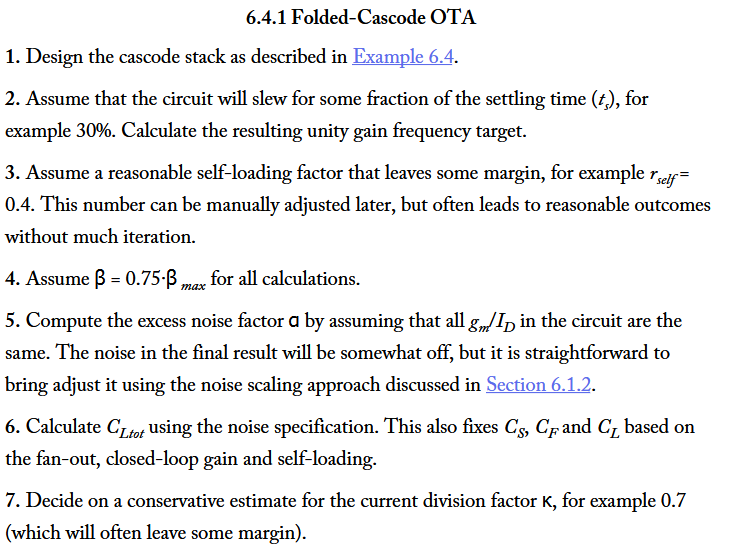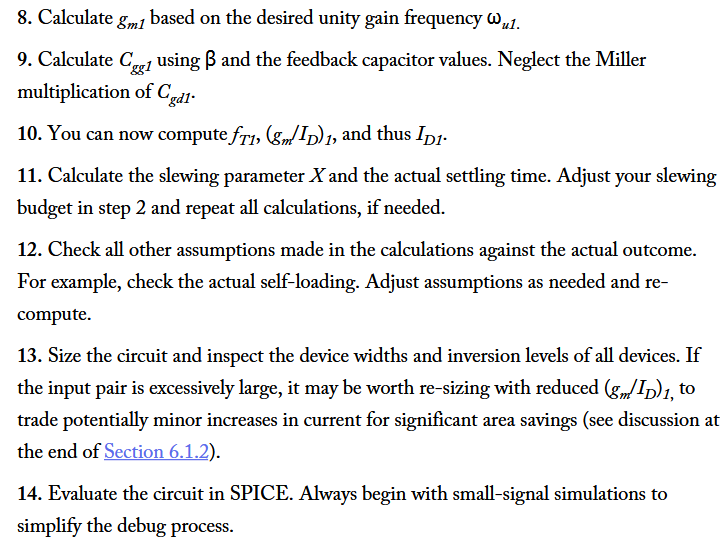

2 MOS pour 0.45000000000000007
gm_id >  8.888888888888888
On prend gm_id = 12


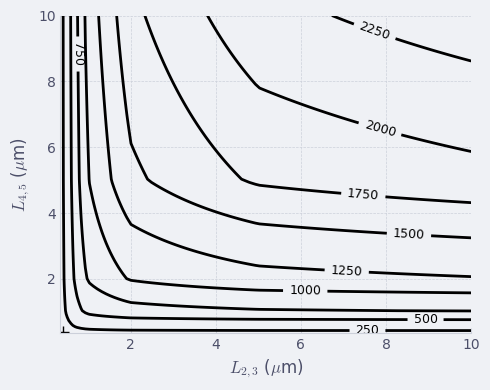

On prend L23 = 1.8
Nondominant pole frequency: 0.102 GHz
FP2 / FU1 == 4 for 75° phase margin and fatest settling
fp2 / s['fu1'] = np.float64(4.210958280565062)


In [9]:
def folded_cascode_simplified(nmoslk, pmoslk, s, d): ##Version Matriced
    """
    Size a folded-cascode amplifier using the gm/ID methodology.

    Sweeps β and gm/ID simultaneously to find the design points that meet
    the noise and speed specifications, then computes the self-loading
    capacitance at each point.

    nmoslk / pmoslk are gm/ID lookup tables for the NMOS and PMOS devices.

    s must contain:
        fu1       — unity-gain frequency (Hz)
        vod_noise — output-referred noise voltage (V)
        FO        — fan-out
        G         — closed-loop gain
        vod_final — voltage ouput step max
        ed — erreur settling %

    d must contain:
        gm_ID1   — gm/ID sweep vector for the input transistor (S/A)
        beta     — feedback factor sweep vector
        L1       — input transistor length (µm)
        Lcas     — cascode length (µm)
        gm_IDcas — cascode gm/ID operating point (S/A)
        gamma    — excess noise coefficient
        cself    — self-loading estimate, set to 0 on first pass (F)

    Returns m1 (ID, gm_ID) and p (cltot, cself) at each matched design point.
    """
    kB = 1.3806488e-23
    temp = 300
    # ── Device lookups over the gm/ID sweep vector ────────────────────────────
    gm_gds1  = pmoslk.look_up('GM_GDS',  GM_ID=d['gm_ID1'],   L=d['L1'])
    wt1      = pmoslk.look_up('GM_CGG',  GM_ID=d['gm_ID1'],   L=d['L1'])
    cgd_cgg1 = pmoslk.look_up('CGD_CGG', GM_ID=d['gm_ID1'],   L=d['L1'])
    gm_gds2  = nmoslk.look_up('GM_GDS',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm3  = nmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm4  = pmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])

    # ── Step 2 : sweep β — broadcast to 2D (N_beta, N_gm_ID1) ────────────────
    beta   = d['beta'][:, None]    # (N, 1)
    gm_ID1 = d['gm_ID1'][None, :] # (1, M)

    # Step 3a. Excess noise factor α (eq. 6.54)
    alpha = 2 * d['gamma'] * (1 + 3 * d['gm_IDcas'] / gm_ID1)

    # Step 3b. C_Ltot from noise spec (eq. 6.53) — also fixes C_S, C_F, C_L
    cltot = alpha / beta * kB * temp / (s['vod_noise']**2)
    CF    = (cltot - d['cself']) / (s['FO'] * s['G'] + 1 - beta)
    CS    = s['G'] * CF
    CL   = s['FO'] * CS
    # Step 3c. Current division factor κ (eq. 6.43)
    kappa = 1 / (1 + gm_ID1 / (gm_gds1 * d['gm_IDcas']) + 2 / gm_gds2)

    #Slewing compute X, then more accurate wu1 
    ######### Simpliifed version
    ###############X = s['vod_final'] * beta / 2 * gm_ID1
    ###############wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))

    # Step 3d. g_m1 from settling formula above 
    gm1 = 2 * np.pi * s['fu1'] * cltot / (beta * kappa)
    ###############gm1 = wu1 * cltot / (beta * kappa)

    # Step 3e. I_D1 and f_Ti from the gm/ID vector
    ID1 = gm1 / gm_ID1

    # Step 3f. C_gg1 from g_m and f_Ti → compute C_gd1 and C_in (eq. 6.47)
    cgs1 = gm1 / wt1
    cin  = cgs1 * (1 + cgd_cgg1 * gm_ID1 / d['gm_IDcas'])

    # Step 3g. Actual β values along the gm/ID vector (eq. 6.46)
    beta_actual = CF / (CF + CS + cin)

    # ── Step 4 : find closest match between β_actual and β_k ─────────────────
    idx = np.argmin(np.abs(beta_actual - beta), axis=1)  # (N,)
    j   = np.arange(len(d['beta']))

    # ── Step 5 : collect design point that minimises current; compute r_self ──

    m1_gm1 = gm1[j, idx]
    m1_gm_id1 = d['gm_ID1'][idx]





    # Using lookup to get current densities
    ID1 = m1_gm1 / m1_gm_id1
    ID_W1 = pmos4.look_up( 'ID_W', GM_ID=m1_gm_id1, L=d['L1'])
    ID_W2 = nmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)
    ID_W5 = pmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)
    # Calculating widths
    W1 = ID1 / ID_W1
    W2 = 2 * ID1 / ID_W2
    W3 = W2 / 2
    W5 = ID1 / ID_W5
    W4 = W5
    #######Calc GAIN
    gds5    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * ID1
    gds4    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gm4     = pmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gds3    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gm3     = nmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2) * ID1
    gds2    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * 2 * ID1
    gds1    = pmos4.look_up( 'GDS_ID', GM_ID=m1_gm_id1, L=d['L1']) * 2 * ID1
    gds_gm1    = pmos4.look_up( 'GDS_GM', GM_ID=m1_gm_id1, L=d['L1'])
    gm_gds2    = nmos4.look_up( 'GM_GDS', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6)

    rout = 1 / ( gds4 / (1+gm4/gds5) + gds3 / (1 + gm3 / (gds1+gds2) ))
    kappa = 1 / ( 1 + gds1 / gm3 + 2 / gm_gds2)
    L0 = 20*np.log10(beta * kappa * m1_gm1 * rout)

    m1 = {
        'ID':    ID1, 'gm' : m1_gm1,
        'gm_ID': m1_gm_id1,'W': W1,'L': d['L1'],
    }
    m2 = {
        'ID':    2 * ID1,
        'gm_ID': d['gm_IDcas'],'W2': W2,'L1': d['Lcas'],
    }
    m3 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W3,'L': d['Lcas'],
    }
    m4 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W4,'L': d['Lcas'],
    }
    m5 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W5,'L': d['Lcas'],
    }
    p = {
        'cltot': cltot[j, idx],
        'cself': m1['ID'] * d['gm_IDcas'] * (cdd_gm3 + cdd_gm4),  # → r_self = cself/cltot
        'CF' : CF,
        'CL' : CL,
        'CS' : CS,
        'L0' : L0,
    }
    return m1,m2,m3,m4,m5, p


#STEP 1 : Sizing the output branch
##Spec
##L0 > 50 & V_SWING_P2P_DIFF = 1.8
G = 1/4
beta_max = 1 / (1 + G)
beta = 3/4 * beta_max
kappa = 0.7
#Vout_cm = 1.35
###Choose gm_id with output common mode
#Vout_swing = 1.8 p2p_diff -> each output 0.9 p2p -> 1.35 +- 0.45
VDD = 2.7
VCM = 1.35
V_SWING_P2P_DIFF = 1.8
VOUT_CM_HIGH = VCM+V_SWING_P2P_DIFF/2
VOUT_CM_LOW = VCM-V_SWING_P2P_DIFF/2
print('2 MOS pour', VOUT_CM_LOW)
gm_id = 2/(VOUT_CM_LOW/2)
print('gm_id > ', gm_id)
print('On prend gm_id = 12')
##On prend gm_id = 15
gm_ID_cascode = 12

###Choose L with gain target, calc gain pour plot

L = np.linspace(0.35, 10, 100)

gm_gds2 = nmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.2, VSB = 0)
gm_gds3 = nmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.4, VSB = -0.2)
gm_gds4 = pmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.4, VSB = -0.2)
gm_gds5 = pmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.2, VSB = 0)

L0 = np.zeros((len(L), len(L)))

for i in range(len(L)):
    L0[i, :] = beta * kappa / (1/((1+gm_gds5)*gm_gds4) + 1/((1+1/3*gm_gds2[i])*gm_gds3[i]))

# Plotting
fig, ax = plt.subplots(figsize=(5, 4))

C = ax.contour(L, L, L0, colors='k', levels= 10)
ax.clabel(C, fmt='%d', fontsize=9)
ax.set_xlabel(r'$L_{2,3}$ ($\mu$m)')
ax.set_ylabel(r'$L_{4,5}$ ($\mu$m)')
ax.plot(0.4, 0.4, 'k+', markersize=9, linewidth=20)
plt.tight_layout()
plt.show()

#Choose length
L_cascode = 1.8
print('On prend L23 =', L_cascode)
gmb_gm3 =   nmos4.lookup('GMB_GM', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
gm_css3 =   nmos4.lookup('GM_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_css3 =  nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_w3  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_w2  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.2, VSB = 0)

# Nondominant pole frequency
fp2 = 1 / (2 * np.pi) * gm_css3 * (1 + gmb_gm3) / (1 + 2 * cdd_css3 * 2 * (cdd_w2 / cdd_w3))
print(f'Nondominant pole frequency: {fp2 * 1e-9:.3f} GHz')

#Step2 : 
s = {
    'ts'        : 50e-9,
    'ed'        : 0.05/100,
    'fu1'       : 1/(2*np.pi) * np.log(1/ (0.1/100)) / 50e-9,
    'vod_noise' : 90e-6,
    'FO'        : 4,
    'G'         : 1/4,
    'vod_final' : 0.160
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']
d = {
    'gamma': 0.8,
    'Lcas': L_cascode,
    'gm_IDcas': gm_ID_cascode,
    'L1' : 0.5,
    'cself': 0.4,
    'gm_ID1': np.array([15]),
    'beta': np.array([beta_max * 3/4])
}
#Simplified parameter
d['cself'] = 0
d['beta'] = np.array([beta_max * 3/4])
d['gm_ID1'] = np.array([18])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts'] * 1
X = 0
for i in range(5):
    #adri.cool_print(d['cself'])
    m1,m2,m3,m4,m5,p = folded_cascode_simplified(nmos4, pmos4, s, d)
    #adri.cool_print(m1['gm'])
    d['cself'] = p['cself']
    X = s['vod_final'] * d['beta'] / 2 * m1['gm_ID']
    actual_ts = 1 / s['fu1'] / (2 * np.pi) * (X - 1 + np.log(1/(s['ed'] * X))   ) 
    # wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))
    # s['fu1'] =  wu1.item() / (2 * np.pi)
    #adri.cool_print(actual_ts)



print("FP2 / FU1 == 4 for 75° phase margin and fatest settling")
adri.cool_print(fp2 / s['fu1'])
print_design_summary(s, d,m1,m2,m3,m4,p)

###TODO : 
# Compute FP2 / FU1 pour viser 4 et avoir 75° phase margin

## ALl in one cell

2 MOS pour 0.45000000000000007
gm_id >  8.888888888888888
On prend gm_id = 12


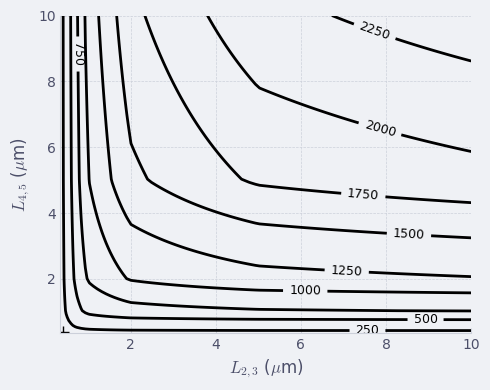

On prend L23 = 1.8
Nondominant pole frequency: 0.102 GHz
FP2 / FU1 == 4 for 75° phase margin and fatest settling
fp2 / s['fu1'] = np.float64(4.210958280565062)


In [10]:
import numpy as np
import scipy.constants as sc
import catppuccin
import adri
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
#import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)
from IPython.display import display, HTML
import inspect, re
def print_design_summary(*args):
    # Récupère les noms des variables depuis l'appel
    frame = inspect.currentframe().f_back
    call_source = inspect.getframeinfo(frame).code_context[0].strip()
    match = re.search(r'print_design_summary\((.*)\)', call_source)
    if match:
        arg_names = [a.strip() for a in match.group(1).split(',')]
    else:
        arg_names = [f"Block {i}" for i in range(len(args))]

    def make_table(title, blk):
        items = [(k, fmt(np.asarray(v).flat[0] if not np.isscalar(v) else v, k))
                 for k, v in blk.items()]
        header = (f"<tr><td colspan='2' style='padding:8px 0 3px; font-size:20px; "
                  f"letter-spacing:.1em; opacity:.5; text-transform:uppercase; "
                  f"border-top:1px solid currentColor;'>{title}</td></tr>")
        rows = "".join(
            f"<tr><td style='padding:1px 4px 1px 0; opacity:.6; white-space:nowrap'>{k}</td>"
            f"<td style='padding:1px 0; text-align:right; font-variant-numeric:tabular-nums; "
            f"font-weight:500; white-space:nowrap'>{v}</td></tr>"
            for k, v in items)
        footer = "<tr><td colspan='2' style='border-top:1px solid currentColor; padding-top:2px'></td></tr>"
        return (f"<table style='font-family:monospace; font-size:18px; border-collapse:collapse; "
                f"color:inherit; vertical-align:top'>{header}{rows}{footer}</table>")

    tables = ""
    for name, blk in zip(arg_names, args):
        tables += f"<td style='vertical-align:top; padding-right:0px'>{make_table(name, blk)}</td>"

    display(HTML(
        f"<table style='color:inherit; border-spacing:; border-collapse:collapse'>"
        f"<tr>{tables}</tr></table>"
    ))
def fmt(val, key=""):
    if not isinstance(val, (int, float, np.floating)):
        return str(val)
    a = abs(val)
    if   a >= 1e9:  return f"{val/1e9:.4g} G"
    elif a >= 1:    return f"{val:.4g}"
    elif a >= 1e-3: return f"{val/1e-3:.4g} m"
    elif a >= 1e-6: return f"{val/1e-6:.4g} u"
    elif a >= 1e-9: return f"{val/1e-9:.4g} n"
    elif a >= 1e-12:return f"{val/1e-12:.4g} p"
    else:           return f"{val:.4e}"
def folded_cascode_simplified(nmoslk, pmoslk, s, d): ##Version Matriced
    """
    Size a folded-cascode amplifier using the gm/ID methodology.

    Sweeps β and gm/ID simultaneously to find the design points that meet
    the noise and speed specifications, then computes the self-loading
    capacitance at each point.

    nmoslk / pmoslk are gm/ID lookup tables for the NMOS and PMOS devices.

    s must contain:
        fu1       — unity-gain frequency (Hz)
        vod_noise — output-referred noise voltage (V)
        FO        — fan-out
        G         — closed-loop gain
        vod_final — voltage ouput step max
        ed — erreur settling %

    d must contain:
        gm_ID1   — gm/ID sweep vector for the input transistor (S/A)
        beta     — feedback factor sweep vector
        L1       — input transistor length (µm)
        Lcas     — cascode length (µm)
        gm_IDcas — cascode gm/ID operating point (S/A)
        gamma    — excess noise coefficient
        cself    — self-loading estimate, set to 0 on first pass (F)

    Returns m1 (ID, gm_ID) and p (cltot, cself) at each matched design point.
    """
    kB = 1.3806488e-23
    temp = 300
    # ── Device lookups over the gm/ID sweep vector ────────────────────────────
    gm_gds1  = pmoslk.look_up('GM_GDS',  GM_ID=d['gm_ID1'],   L=d['L1'])
    wt1      = pmoslk.look_up('GM_CGG',  GM_ID=d['gm_ID1'],   L=d['L1'])
    cgd_cgg1 = pmoslk.look_up('CGD_CGG', GM_ID=d['gm_ID1'],   L=d['L1'])
    gm_gds2  = nmoslk.look_up('GM_GDS',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm3  = nmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])
    cdd_gm4  = pmoslk.look_up('CDD_GM',  GM_ID=d['gm_IDcas'], L=d['Lcas'])

    # ── Step 2 : sweep β — broadcast to 2D (N_beta, N_gm_ID1) ────────────────
    beta   = d['beta'][:, None]    # (N, 1)
    gm_ID1 = d['gm_ID1'][None, :] # (1, M)

    # Step 3a. Excess noise factor α (eq. 6.54)
    alpha = 2 * d['gamma'] * (1 + 3 * d['gm_IDcas'] / gm_ID1)

    # Step 3b. C_Ltot from noise spec (eq. 6.53) — also fixes C_S, C_F, C_L
    cltot = alpha / beta * kB * temp / (s['vod_noise']**2)
    CF    = (cltot - d['cself']) / (s['FO'] * s['G'] + 1 - beta)
    CS    = s['G'] * CF
    CL   = s['FO'] * CS
    # Step 3c. Current division factor κ (eq. 6.43)
    kappa = 1 / (1 + gm_ID1 / (gm_gds1 * d['gm_IDcas']) + 2 / gm_gds2)

    #Slewing compute X, then more accurate wu1 
    ######### Simpliifed version
    ###############X = s['vod_final'] * beta / 2 * gm_ID1
    ###############wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))

    # Step 3d. g_m1 from settling formula above 
    gm1 = 2 * np.pi * s['fu1'] * cltot / (beta * kappa)
    ###############gm1 = wu1 * cltot / (beta * kappa)

    # Step 3e. I_D1 and f_Ti from the gm/ID vector
    ID1 = gm1 / gm_ID1

    # Step 3f. C_gg1 from g_m and f_Ti → compute C_gd1 and C_in (eq. 6.47)
    cgs1 = gm1 / wt1
    cin  = cgs1 * (1 + cgd_cgg1 * gm_ID1 / d['gm_IDcas'])

    # Step 3g. Actual β values along the gm/ID vector (eq. 6.46)
    beta_actual = CF / (CF + CS + cin)

    # ── Step 4 : find closest match between β_actual and β_k ─────────────────
    idx = np.argmin(np.abs(beta_actual - beta), axis=1)  # (N,)
    j   = np.arange(len(d['beta']))

    # ── Step 5 : collect design point that minimises current; compute r_self ──

    m1_gm1 = gm1[j, idx]
    m1_gm_id1 = d['gm_ID1'][idx]





    # Using lookup to get current densities
    ID1 = m1_gm1 / m1_gm_id1
    ID_W1 = pmos4.look_up( 'ID_W', GM_ID=m1_gm_id1, L=d['L1'])
    ID_W2 = nmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)
    ID_W5 = pmos4.look_up( 'ID_W', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.2)
    # Calculating widths
    W1 = ID1 / ID_W1
    W2 = 2 * ID1 / ID_W2
    W3 = W2 / 2
    W5 = ID1 / ID_W5
    W4 = W5
    #######Calc GAIN
    gds5    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * ID1
    gds4    = pmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gm4     = pmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gds3    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2, VSB = -0.6) * ID1
    gm3     = nmos4.look_up( 'GM_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=1.2) * ID1
    gds2    = nmos4.look_up( 'GDS_ID', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6) * 2 * ID1
    gds1    = pmos4.look_up( 'GDS_ID', GM_ID=m1_gm_id1, L=d['L1']) * 2 * ID1
    gds_gm1    = pmos4.look_up( 'GDS_GM', GM_ID=m1_gm_id1, L=d['L1'])
    gm_gds2    = nmos4.look_up( 'GM_GDS', GM_ID=d['gm_IDcas'], L=d['Lcas'], VDS=0.6)

    rout = 1 / ( gds4 / (1+gm4/gds5) + gds3 / (1 + gm3 / (gds1+gds2) ))
    kappa = 1 / ( 1 + gds1 / gm3 + 2 / gm_gds2)
    L0 = 20*np.log10(beta * kappa * m1_gm1 * rout)

    m1 = {
        'ID':    ID1, 'gm' : m1_gm1,
        'gm_ID': m1_gm_id1,'W': W1,'L': d['L1'],
    }
    m2 = {
        'ID':    2 * ID1,
        'gm_ID': d['gm_IDcas'],'W2': W2,'L1': d['Lcas'],
    }
    m3 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W3,'L': d['Lcas'],
    }
    m4 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W4,'L': d['Lcas'],
    }
    m5 = {
        'ID':    ID1,
        'gm_ID': d['gm_IDcas'],'W': W5,'L': d['Lcas'],
    }
    p = {
        'cltot': cltot[j, idx],
        'cself': m1['ID'] * d['gm_IDcas'] * (cdd_gm3 + cdd_gm4),  # → r_self = cself/cltot
        'CF' : CF,
        'CL' : CL,
        'CS' : CS,
        'L0' : L0,
    }
    return m1,m2,m3,m4,m5, p


#STEP 1 : Sizing the output branch
##Spec
##L0 > 50 & V_SWING_P2P_DIFF = 1.8
G = 1/4
beta_max = 1 / (1 + G)
beta = 3/4 * beta_max
kappa = 0.7
#Vout_cm = 1.35
###Choose gm_id with output common mode
#Vout_swing = 1.8 p2p_diff -> each output 0.9 p2p -> 1.35 +- 0.45
VDD = 2.7
VCM = 1.35
V_SWING_P2P_DIFF = 1.8
VOUT_CM_HIGH = VCM+V_SWING_P2P_DIFF/2
VOUT_CM_LOW = VCM-V_SWING_P2P_DIFF/2
print('2 MOS pour', VOUT_CM_LOW)
gm_id = 2/(VOUT_CM_LOW/2)
print('gm_id > ', gm_id)
print('On prend gm_id = 12')
##On prend gm_id = 15
gm_ID_cascode = 12

###Choose L with gain target, calc gain pour plot

L = np.linspace(0.35, 10, 100)

gm_gds2 = nmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.2, VSB = 0)
gm_gds3 = nmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.4, VSB = -0.2)
gm_gds4 = pmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.4, VSB = -0.2)
gm_gds5 = pmos4.lookup('GM_GDS', GM_ID = gm_ID_cascode, L = L, VDS = 0.2, VSB = 0)

L0 = np.zeros((len(L), len(L)))

for i in range(len(L)):
    L0[i, :] = beta * kappa / (1/((1+gm_gds5)*gm_gds4) + 1/((1+1/3*gm_gds2[i])*gm_gds3[i]))

# Plotting
fig, ax = plt.subplots(figsize=(5, 4))

C = ax.contour(L, L, L0, colors='k', levels= 10)
ax.clabel(C, fmt='%d', fontsize=9)
ax.set_xlabel(r'$L_{2,3}$ ($\mu$m)')
ax.set_ylabel(r'$L_{4,5}$ ($\mu$m)')
ax.plot(0.4, 0.4, 'k+', markersize=9, linewidth=20)
plt.tight_layout()
plt.show()

#Choose length
L_cascode = 1.8
print('On prend L23 =', L_cascode)
gmb_gm3 =   nmos4.lookup('GMB_GM', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
gm_css3 =   nmos4.lookup('GM_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_css3 =  nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_w3  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.4, VSB = -0.2)
cdd_w2  =   nmos4.lookup('CDD_CSS', GM_ID = gm_ID_cascode, L = L_cascode, VDS = 0.2, VSB = 0)

# Nondominant pole frequency
fp2 = 1 / (2 * np.pi) * gm_css3 * (1 + gmb_gm3) / (1 + 2 * cdd_css3 * 2 * (cdd_w2 / cdd_w3))
print(f'Nondominant pole frequency: {fp2 * 1e-9:.3f} GHz')

#Step2 : 
s = {
    'ts'        : 50e-9,
    'ed'        : 0.05/100,
    'fu1'       : 1/(2*np.pi) * np.log(1/ (0.1/100)) / 50e-9,
    'vod_noise' : 90e-6,
    'FO'        : 4,
    'G'         : 1/4,
    'vod_final' : 0.160
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']
d = {
    'gamma': 0.8,
    'Lcas': L_cascode,
    'gm_IDcas': gm_ID_cascode,
    'L1' : 0.5,
    'cself': 0.4,
    'gm_ID1': np.array([15]),
    'beta': np.array([beta_max * 3/4])
}
#Simplified parameter
d['cself'] = 0
d['beta'] = np.array([beta_max * 3/4])
d['gm_ID1'] = np.array([18])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts'] * 1
X = 0
for i in range(5):
    #adri.cool_print(d['cself'])
    m1,m2,m3,m4,m5,p = folded_cascode_simplified(nmos4, pmos4, s, d)
    #adri.cool_print(m1['gm'])
    d['cself'] = p['cself']
    X = s['vod_final'] * d['beta'] / 2 * m1['gm_ID']
    actual_ts = 1 / s['fu1'] / (2 * np.pi) * (X - 1 + np.log(1/(s['ed'] * X))   ) 
    # wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))
    # s['fu1'] =  wu1.item() / (2 * np.pi)
    #adri.cool_print(actual_ts)



print("FP2 / FU1 == 4 for 75° phase margin and fatest settling")
adri.cool_print(fp2 / s['fu1'])
print_design_summary(s, d,m1,m2,m3,m4,p)

###TODO : 
# Compute FP2 / FU1 pour viser 4 et avoir 75° phase margin